# EMBER Dataset — Exploratory Data Analysis
> Elastic Malware Benchmark for Empowering Researchers  
> Paper: [arxiv:1804.04637](https://arxiv.org/abs/1804.04637) · Repo: [github.com/elastic/ember](https://github.com/elastic/ember)

## 0. Setup & Installation

In [90]:
# Install dependencies (run once)
# !pip install git+https://github.com/elastic/ember.git
# !pip install lightgbm lief==0.9.0 pandas numpy matplotlib seaborn scikit-learn tqdm

In [1]:
import os
import json
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Try importing ember (requires install above)
try:
    import ember
    EMBER_AVAILABLE = True
    print("ember module loaded successfully")
except ImportError:
    EMBER_AVAILABLE = False
    print("ember module not found — raw JSONL parsing will be used")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = {
    'malicious': '#e24b4a',
    'benign':    '#639922',
    'unlabeled': '#888780',
    'blue':      '#378add',
    'purple':    '#534ab7',
    'teal':      '#1d9e75',
    'amber':     '#ef9f27',
}

print("Setup complete.")

ember module loaded successfully
Setup complete.


## 1. Load the Dataset

Download from https://ember.elastic.co/ember_dataset_2018_2.tar.bz2 then set `DATA_DIR` below.

In [2]:
# ── CONFIGURE THIS ──────────────────────────────────────────────
DATA_DIR = "./data/ember2018/"   # path to extracted dataset
SAMPLE_N  = None             # samples to load for EDA (set None for full dataset) ex. 100_000
# ────────────────────────────────────────────────────────────────

def load_jsonl_gz(path, n=None):
    """Stream JSONL (optionally gzipped) into a list of dicts."""
    records = []
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(tqdm(f, desc=os.path.basename(path))):
            if n and i >= n:
                break
            records.append(json.loads(line))
    return records

def find_train_files(data_dir):
    candidates = [
        ('train_features_5.jsonl', False),
        ('train_features_5.jsonl.gz', True),
    ]
    for name, compressed in candidates:
        p = os.path.join(data_dir, name)
        if os.path.exists(p):
            return p
    # Return any jsonl found
    for f in os.listdir(data_dir):
        if 'train' in f and 'features' in f:
            return os.path.join(data_dir, f)
    raise FileNotFoundError(f"No training JSONL found in {data_dir}")

train_path = find_train_files(DATA_DIR)
print(f"Loading from: {train_path}")
raw_records = load_jsonl_gz(train_path, n=SAMPLE_N)

Loading from: ./data/ember2018/train_features_5.jsonl


train_features_5.jsonl: 0it [00:00, ?it/s]

In [3]:
# Flatten top-level scalar fields into a DataFrame
def flatten_record(rec):
    row = {
        'sha256':         rec.get('sha256', ''),
        'label':          rec.get('label', -1),
        'appeared':       rec.get('appeared', ''),
        # General file info
        'filesize':       rec.get('general', {}).get('size', np.nan),
        'vsize':          rec.get('general', {}).get('vsize', np.nan),
        'has_debug':      rec.get('general', {}).get('has_debug', np.nan),
        'exports':        rec.get('general', {}).get('exports', np.nan),
        'imports':        rec.get('general', {}).get('imports', np.nan),
        'has_relocations':rec.get('general', {}).get('has_relocations', np.nan),
        'has_resources':  rec.get('general', {}).get('has_resources', np.nan),
        'has_signature':  rec.get('general', {}).get('has_signature', np.nan),
        'has_tls':        rec.get('general', {}).get('has_tls', np.nan),
        'symbols':        rec.get('general', {}).get('symbols', np.nan),
        'num_sections':   len(rec.get('section', {}).get('sections', [])),
        # Header
        'timestamp':      rec.get('header', {}).get('coff', {}).get('timestamp', np.nan),
        'machine':        rec.get('header', {}).get('coff', {}).get('machine', ''),
        'subsystem':      rec.get('header', {}).get('optional', {}).get('subsystem', ''),
        # String stats
        'num_strings':    rec.get('strings', {}).get('numstrings', np.nan),
        'avg_str_len':    rec.get('strings', {}).get('avlength', np.nan),
        'str_entropy':    rec.get('strings', {}).get('entropy', np.nan),
        'num_paths':      rec.get('strings', {}).get('paths', np.nan),
        'num_urls':       rec.get('strings', {}).get('urls', np.nan),
        'num_registry':   rec.get('strings', {}).get('registry', np.nan),
        'num_MZ':         rec.get('strings', {}).get('MZ', np.nan),
    }
    return row

df = pd.DataFrame([flatten_record(r) for r in raw_records])
df['label_name'] = df['label'].map({1: 'malicious', 0: 'benign', -1: 'unlabeled'})
df['appeared'] = pd.to_datetime(df['appeared'], format='%Y-%m', errors='coerce')

print(f"Shape: {df.shape}")
df.head(3)

Shape: (202574, 25)


,sha256,label,appeared,filesize,vsize,has_debug,exports,imports,has_relocations,has_resources,...,machine,subsystem,num_strings,avg_str_len,str_entropy,num_paths,num_urls,num_registry,num_MZ,label_name
0,c31950077f3dc66b0decad88326773cb74102c0da3007d...,1,2018-09-01,1353344,3784704,0,0,8,0,1,...,I386,WINDOWS_GUI,6134,5.668569,6.571008,0,0,0,21,malicious
1,3cf15185d9a5b5509e965c5c69ee6dd0a450dd03dd66f0...,-1,2018-09-01,1130496,1384448,0,0,508,0,1,...,I386,WINDOWS_GUI,5280,11.887500,5.893688,1,1,0,8,unlabeled
2,15cbe38aa7edc72790993390e40e2e4e575c9d6ff32947...,0,2018-09-01,39936,61440,1,5,66,1,1,...,AMD64,WINDOWS_GUI,155,16.503226,5.248392,0,0,0,2,benign


## 2. Dataset Overview

In [4]:
print("=" * 50)
print(" EMBER Dataset — Summary")
print("=" * 50)
print(f"\nTotal samples loaded : {len(df):,}")
print(f"Features (columns)   : {len(df.columns)}")
print(f"Date range           : {df['appeared'].min()} → {df['appeared'].max()}")
print("\nLabel distribution:")
print(df['label_name'].value_counts().to_string())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

 EMBER Dataset — Summary

Total samples loaded : 202,574
Features (columns)   : 25
Date range           : 2018-09-01 00:00:00 → 2018-10-01 00:00:00

Label distribution:
label_name
malicious    93521
benign       55662
unlabeled    53391

Missing values:
Series([], )


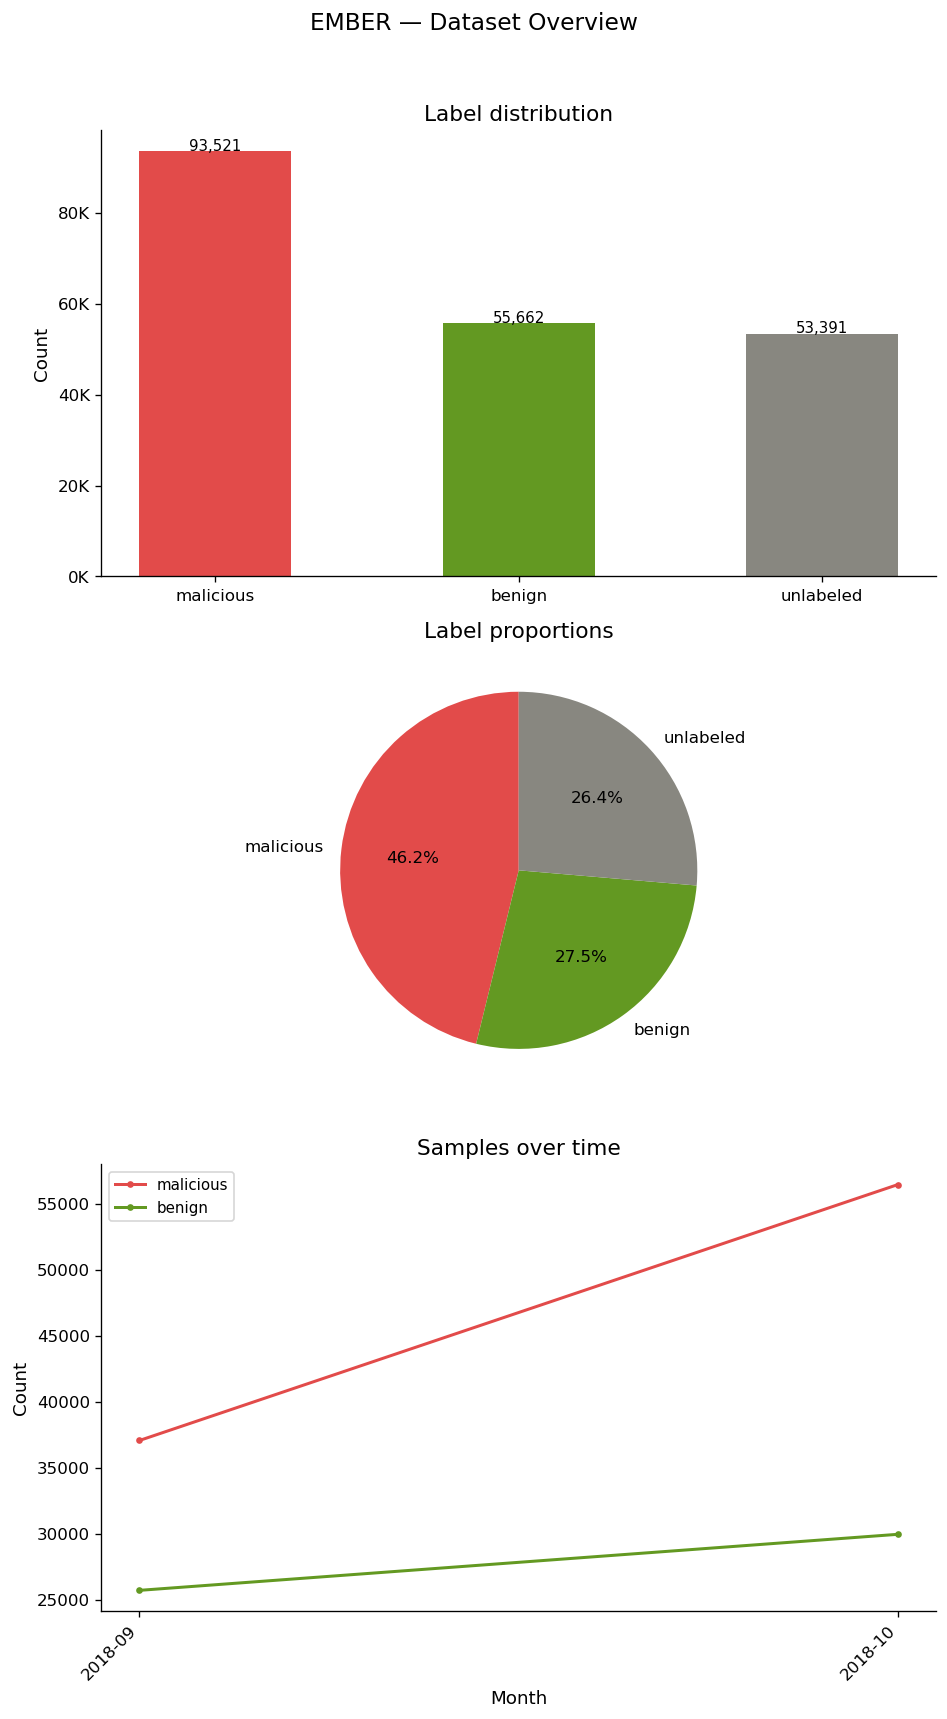

In [8]:
#fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig, axes = plt.subplots(3, 1, figsize=(8, 14))

# Label distribution
counts = df['label_name'].value_counts()
colors = [PALETTE[n] for n in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='none')
axes[0].set_title('Label distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, (v) in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label proportions')

# Temporal distribution
if df['appeared'].notna().sum() > 0:
    for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
        subset = df[df['label_name'] == label].groupby(
            df['appeared'].dt.to_period('M'))['sha256'].count()
        axes[2].plot(subset.index.astype(str), subset.values,
                     label=label, color=color, linewidth=1.8, marker='o', markersize=3)
    axes[2].set_title('Samples over time')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Count')
    axes[2].legend(fontsize=9)
    axes[2].tick_params(axis='x', rotation=45)
    plt.setp(axes[2].xaxis.get_majorticklabels(), ha='right')
else:
    axes[2].text(0.5, 0.5, 'No temporal data\nin this sample',
                 ha='center', va='center', transform=axes[2].transAxes, color='gray')
    axes[2].set_title('Temporal distribution')

plt.suptitle('EMBER — Dataset Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figs/ember_overview.png', bbox_inches='tight')
plt.show()

## 3. File Size Analysis

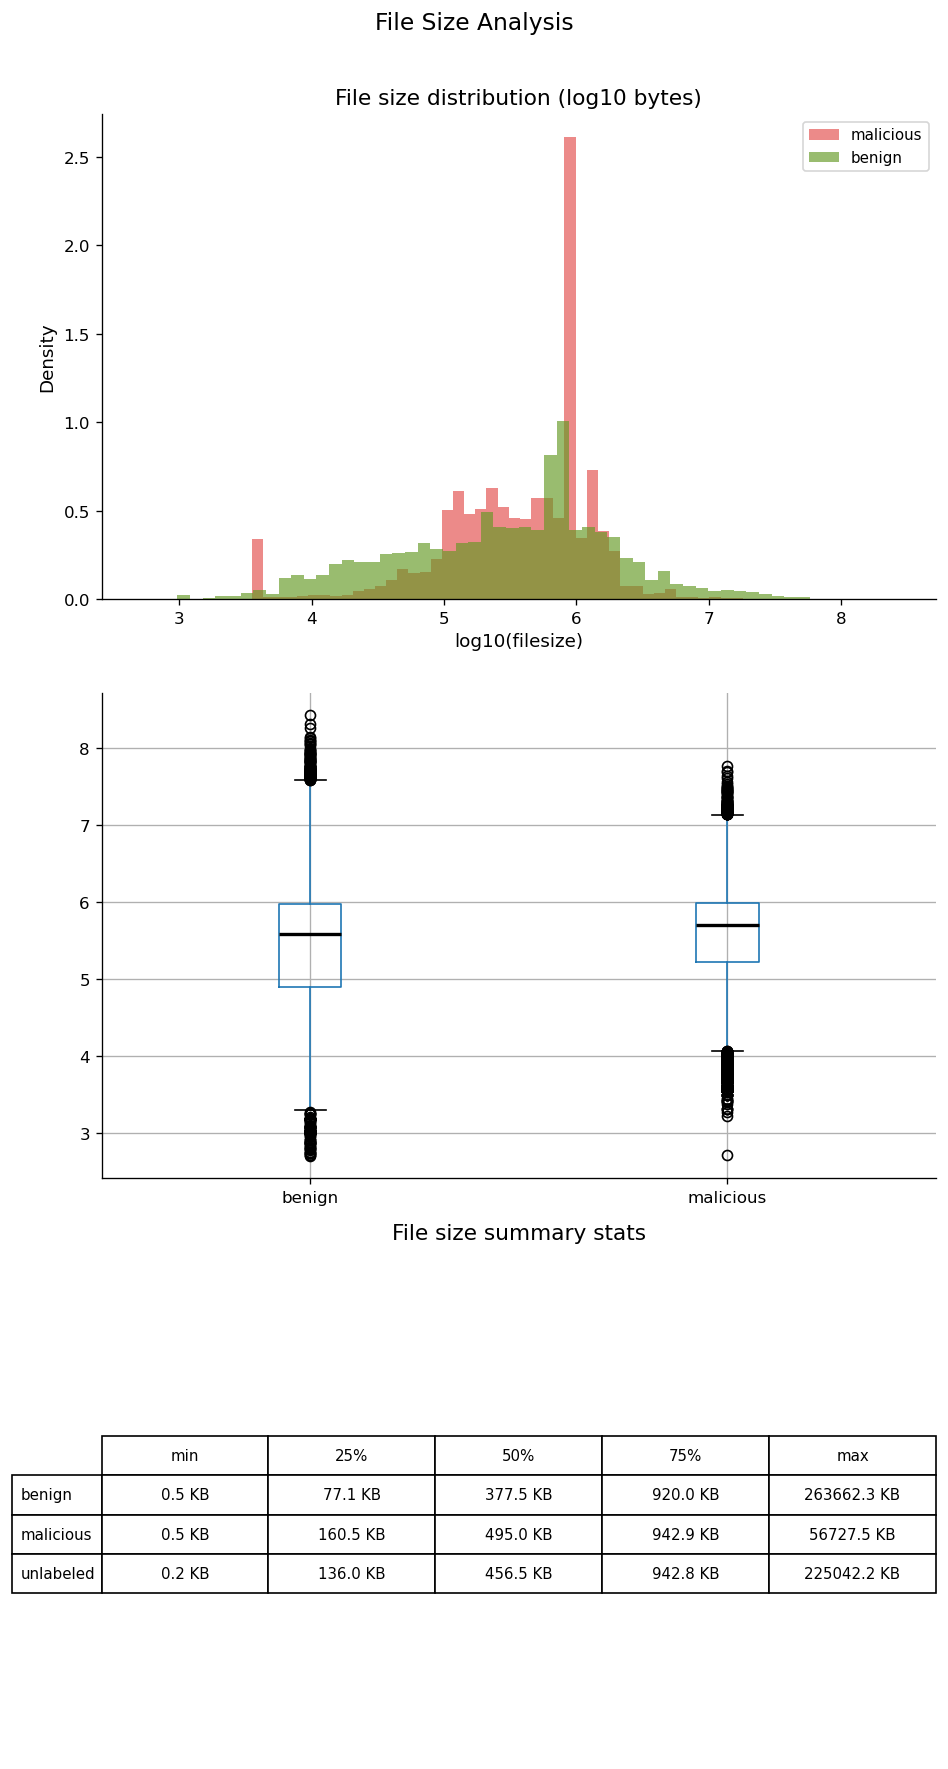

In [7]:
#fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig, axes = plt.subplots(3, 1, figsize=(8, 15)) #vertical format

# Log-scale histogram per label
for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
    sizes = df[df['label_name'] == label]['filesize'].dropna()
    axes[0].hist(np.log10(sizes + 1), bins=60, alpha=0.65,
                 label=label, color=color, density=True, edgecolor='none')
axes[0].set_title('File size distribution (log10 bytes)')
axes[0].set_xlabel('log10(filesize)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Box plot
labeled = df[df['label_name'].isin(['malicious', 'benign'])].copy()
labeled['log_size'] = np.log10(labeled['filesize'] + 1)
labeled.boxplot(column='log_size', by='label_name', ax=axes[1],
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('File size by label')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.title('')

# Summary stats table
stats = df.groupby('label_name')['filesize'].describe()[['min','25%','50%','75%','max']]
stats = stats.applymap(lambda x: f'{x/1024:.1f} KB')
axes[2].axis('off')
tbl = axes[2].table(cellText=stats.values,
                    rowLabels=stats.index,
                    colLabels=stats.columns,
                    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
axes[2].set_title('File size summary stats', pad=20)

plt.suptitle('File Size Analysis', fontsize=14)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('figs/ember_filesize.png', bbox_inches='tight')
plt.show()

## 4. Byte Histogram Analysis

Extracted 3000 byte histograms


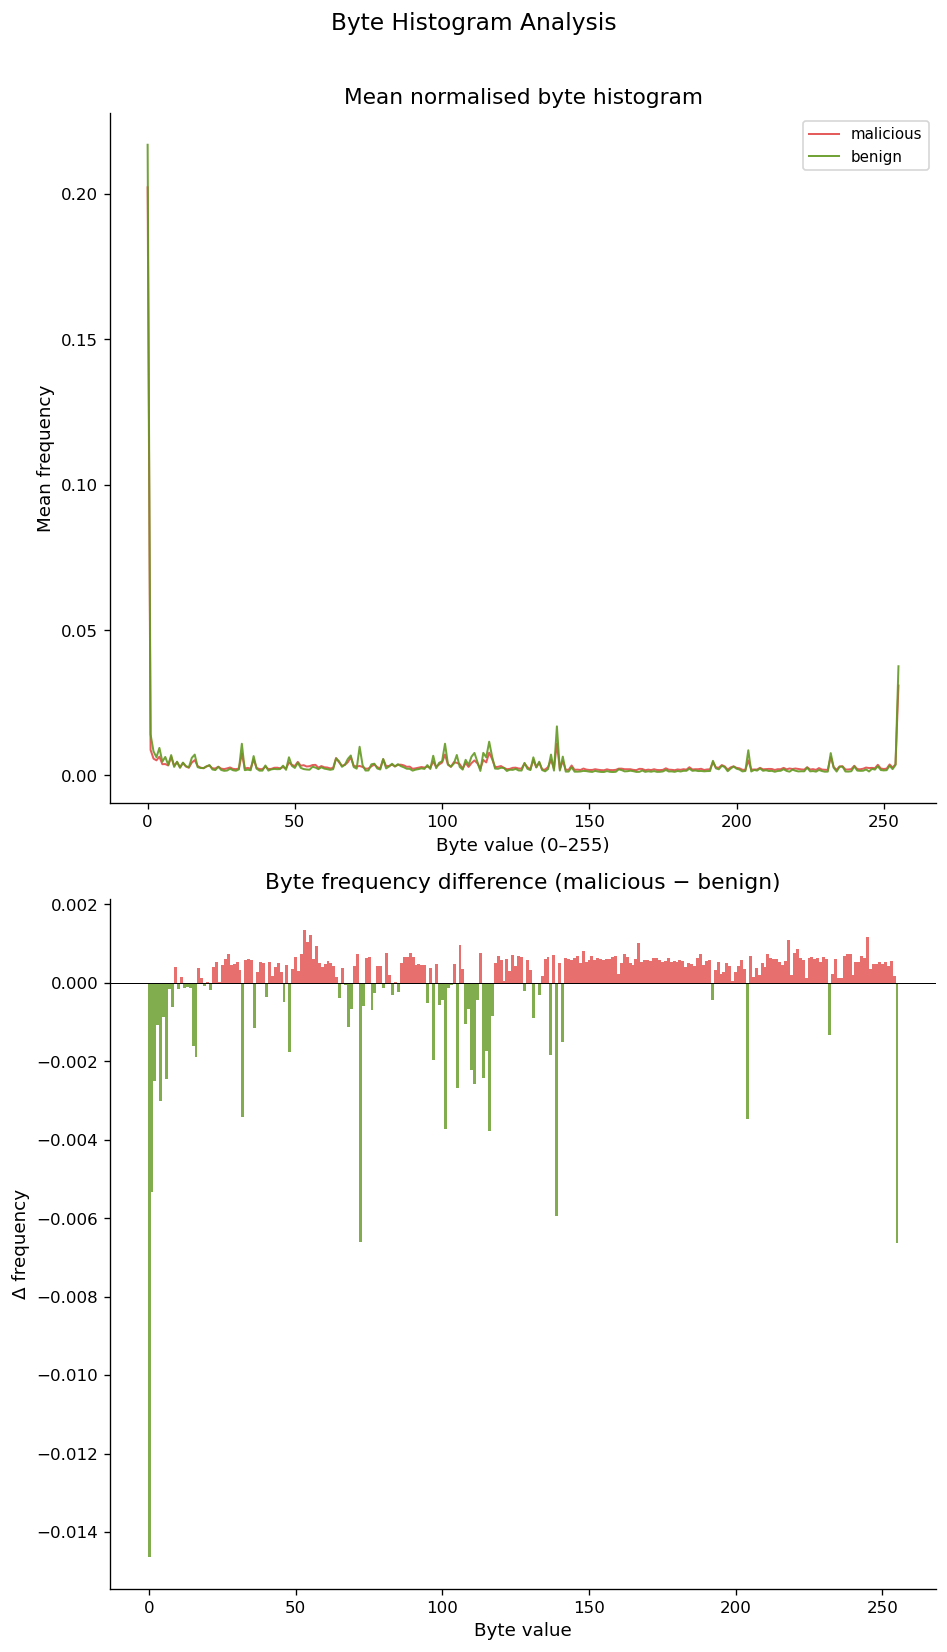

In [10]:
def extract_byte_histograms(records, label_filter=None, n=3000):
    """Extract and optionally filter byte histogram arrays."""
    hists, labels = [], []
    for rec in records:
        lbl = rec.get('label', -1)
        if label_filter is not None and lbl not in label_filter:
            continue
        h = rec.get('histogram', [])
        if len(h) == 256:
            total = sum(h)
            hists.append([v / total if total > 0 else v for v in h])
            labels.append(lbl)
        if len(hists) >= n:
            break
    return np.array(hists), np.array(labels)

byte_hists, byte_labels = extract_byte_histograms(raw_records, label_filter=[0, 1])
print(f"Extracted {len(byte_hists)} byte histograms")

#fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig, axes = plt.subplots(2, 1, figsize=(8, 14))

byte_vals = np.arange(256)
for label, color, name in [(1, PALETTE['malicious'], 'malicious'),
                            (0, PALETTE['benign'],    'benign')]:
    mask = byte_labels == label
    mean_hist = byte_hists[mask].mean(axis=0)
    axes[0].plot(byte_vals, mean_hist, color=color, alpha=0.9, linewidth=1.2, label=name)

axes[0].set_title('Mean normalised byte histogram')
axes[0].set_xlabel('Byte value (0–255)')
axes[0].set_ylabel('Mean frequency')
axes[0].legend(fontsize=9)

# Difference plot
mal_mean = byte_hists[byte_labels == 1].mean(axis=0)
ben_mean = byte_hists[byte_labels == 0].mean(axis=0)
diff = mal_mean - ben_mean
axes[1].bar(byte_vals, diff,
            color=[PALETTE['malicious'] if d > 0 else PALETTE['benign'] for d in diff],
            width=1.0, edgecolor='none', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title('Byte frequency difference (malicious − benign)')
axes[1].set_xlabel('Byte value')
axes[1].set_ylabel('Δ frequency')

plt.suptitle('Byte Histogram Analysis', fontsize=14)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('figs/ember_byte_hist.png', bbox_inches='tight')
plt.show()

## 5. Byte-Entropy Histogram

Extracted 3000 byte-entropy histograms


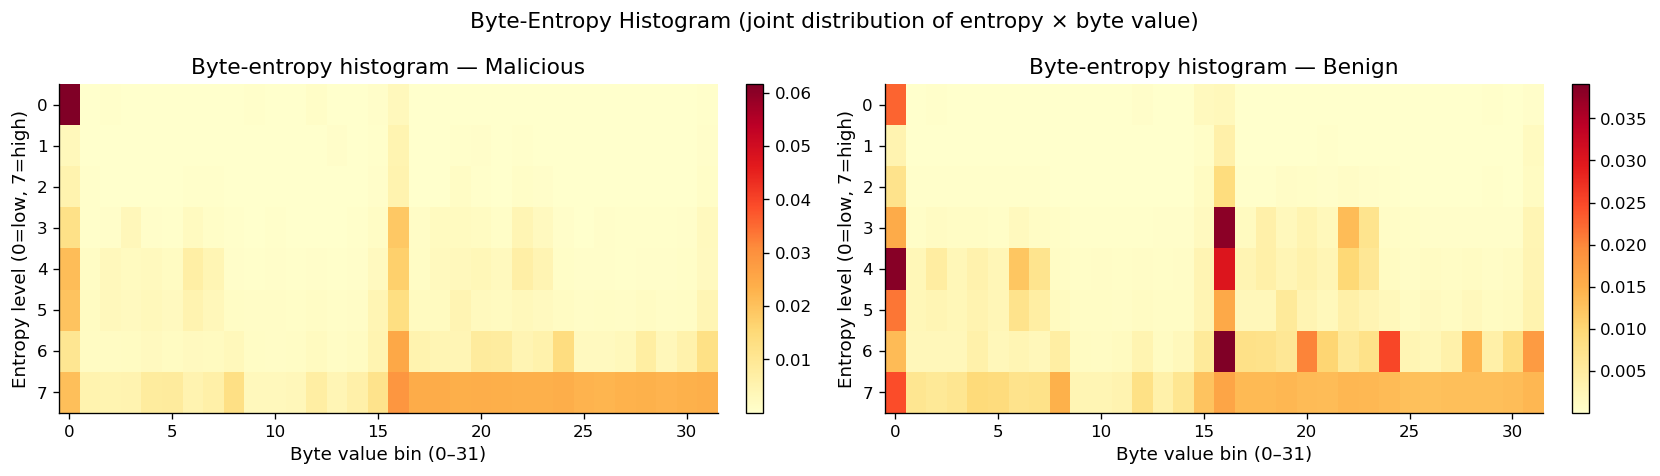

In [98]:
def extract_byte_entropy(records, label_filter=None, n=3000):
    hists, labels = [], []
    for rec in records:
        lbl = rec.get('label', -1)
        if label_filter is not None and lbl not in label_filter:
            continue
        h = rec.get('byteentropy', [])
        if len(h) == 256:
            total = sum(h)
            hists.append([v / total if total > 0 else v for v in h])
            labels.append(lbl)
        if len(hists) >= n:
            break
    return np.array(hists), np.array(labels)

entropy_hists, entropy_labels = extract_byte_entropy(raw_records, label_filter=[0, 1])
print(f"Extracted {len(entropy_hists)} byte-entropy histograms")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# The 256 bins represent an 8x32 grid of (entropy_bin, byte_val) pairs
# Reshape to 8 entropy levels × 32 byte bins for display
for label, color, name, ax in [
    (1, PALETTE['malicious'], 'Malicious', axes[0]),
    (0, PALETTE['benign'],    'Benign',    axes[1])
]:
    mask = entropy_labels == label
    mean_h = entropy_hists[mask].mean(axis=0).reshape(8, 32)
    im = ax.imshow(mean_h, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_title(f'Byte-entropy histogram — {name}')
    ax.set_xlabel('Byte value bin (0–31)')
    ax.set_ylabel('Entropy level (0=low, 7=high)')
    ax.set_yticks(range(8))
    ax.set_yticklabels([f'{i}' for i in range(8)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Byte-Entropy Histogram (joint distribution of entropy × byte value)', fontsize=13)
plt.tight_layout()
plt.savefig('figs/ember_byteentropy.png', bbox_inches='tight')
plt.show()

## 6. String Feature Analysis

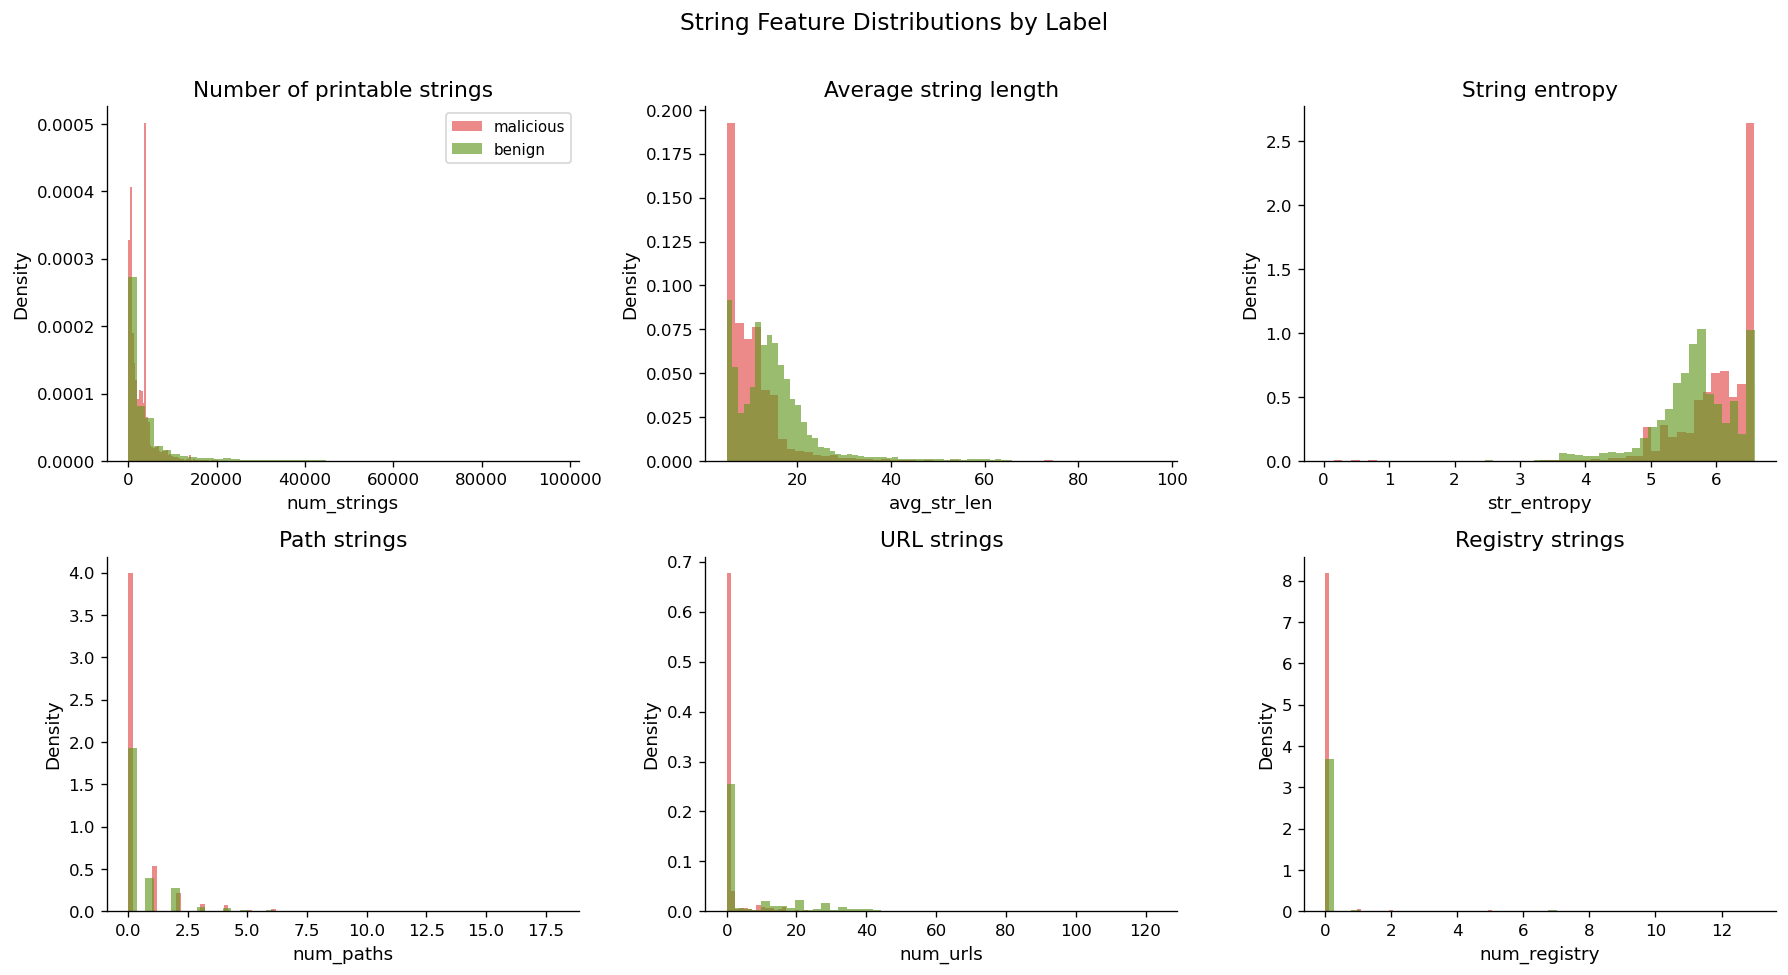


String feature medians by label:
            num_strings  avg_str_len  str_entropy  num_paths  num_urls  num_registry
label_name                                                                          
benign           1701.0        13.91         5.71        0.0       1.0           0.0
malicious        2247.0         8.83         6.18        0.0       0.0           0.0


In [99]:
labeled_df = df[df['label_name'].isin(['malicious', 'benign'])].copy()

string_features = [
    ('num_strings', 'Number of printable strings'),
    ('avg_str_len', 'Average string length'),
    ('str_entropy', 'String entropy'),
    ('num_paths',   'Path strings'),
    ('num_urls',    'URL strings'),
    ('num_registry','Registry strings'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (col, title) in enumerate(string_features):
    ax = axes[idx]
    for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
        vals = labeled_df[labeled_df['label_name'] == label][col].dropna()
        vals = vals[vals < vals.quantile(0.99)]  # clip outliers for readability
        ax.hist(vals, bins=50, alpha=0.65, color=color,
                label=label, density=True, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    if idx == 0:
        ax.legend(fontsize=9)

plt.suptitle('String Feature Distributions by Label', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figs/ember_strings.png', bbox_inches='tight')
plt.show()

# Summary table
print("\nString feature medians by label:")
print(labeled_df.groupby('label_name')[[c for c, _ in string_features]].median().round(2).to_string())

## 7. PE Section Analysis

Extracted 10,003 sections from 2 label classes


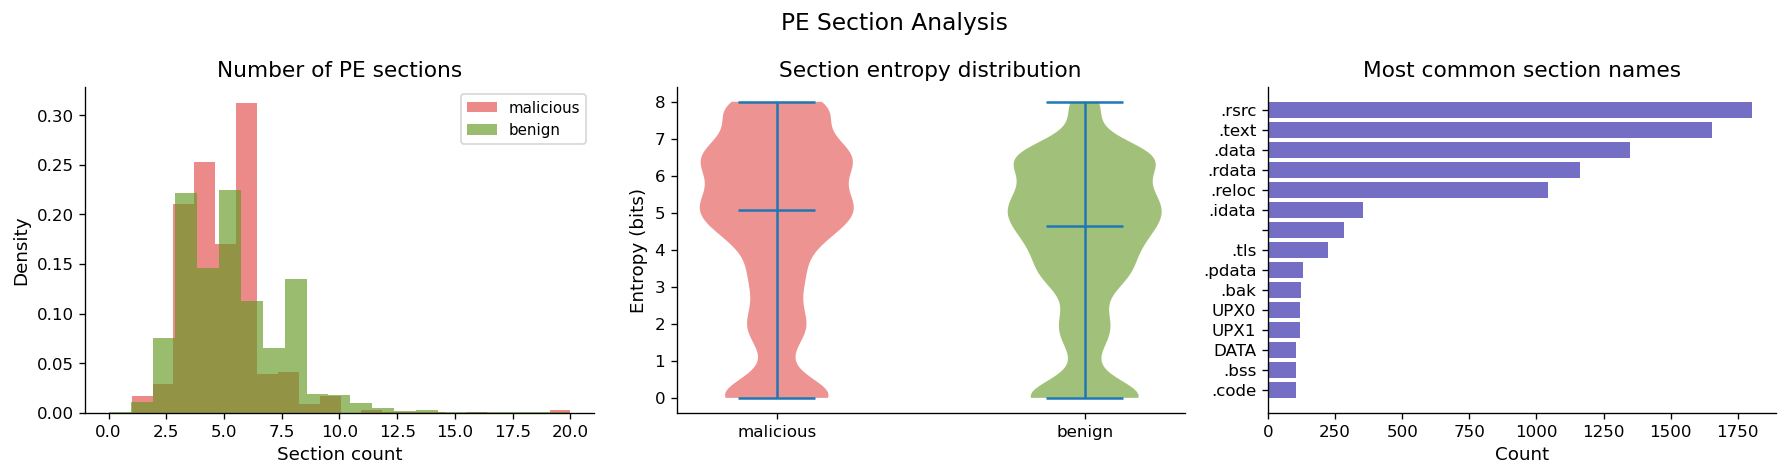

In [100]:
def extract_sections(records, label_filter=None, n=10000):
    rows = []
    for rec in records:
        lbl = rec.get('label', -1)
        if label_filter is not None and lbl not in label_filter:
            continue
        lbl_name = {1: 'malicious', 0: 'benign', -1: 'unlabeled'}.get(lbl, 'unlabeled')
        sections = rec.get('section', {}).get('sections', [])
        for sec in sections:
            rows.append({
                'label': lbl_name,
                'name': sec.get('name', '').strip(),
                'size': sec.get('size', 0),
                'vsize': sec.get('vsize', 0),
                'entropy': sec.get('entropy', 0),
                'props': sec.get('props', []),
            })
        if len(rows) >= n:
            break
    return pd.DataFrame(rows)

sec_df = extract_sections(raw_records, label_filter=[0, 1])
print(f"Extracted {len(sec_df):,} sections from {sec_df['label'].nunique()} label classes")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Section count distribution
for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
    vals = labeled_df[labeled_df['label_name'] == label]['num_sections'].dropna()
    axes[0].hist(vals.clip(0, 20), bins=21, alpha=0.65, color=color, label=label,
                 density=True, edgecolor='none')
axes[0].set_title('Number of PE sections')
axes[0].set_xlabel('Section count')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# 2. Section entropy violin
plot_data = sec_df[sec_df['label'].isin(['malicious', 'benign'])]
parts = axes[1].violinplot(
    [plot_data[plot_data['label'] == 'malicious']['entropy'],
     plot_data[plot_data['label'] == 'benign']['entropy']],
    showmedians=True
)
for i, color in enumerate([PALETTE['malicious'], PALETTE['benign']]):
    parts['bodies'][i].set_facecolor(color)
    parts['bodies'][i].set_alpha(0.6)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['malicious', 'benign'])
axes[1].set_title('Section entropy distribution')
axes[1].set_ylabel('Entropy (bits)')

# 3. Top section names
top_names = sec_df['name'].value_counts().head(15)
axes[2].barh(top_names.index[::-1], top_names.values[::-1],
             color=PALETTE['purple'], edgecolor='none', alpha=0.8)
axes[2].set_title('Most common section names')
axes[2].set_xlabel('Count')

plt.suptitle('PE Section Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('figs/ember_sections.png', bbox_inches='tight')
plt.show()

## 8. Import / Export Analysis

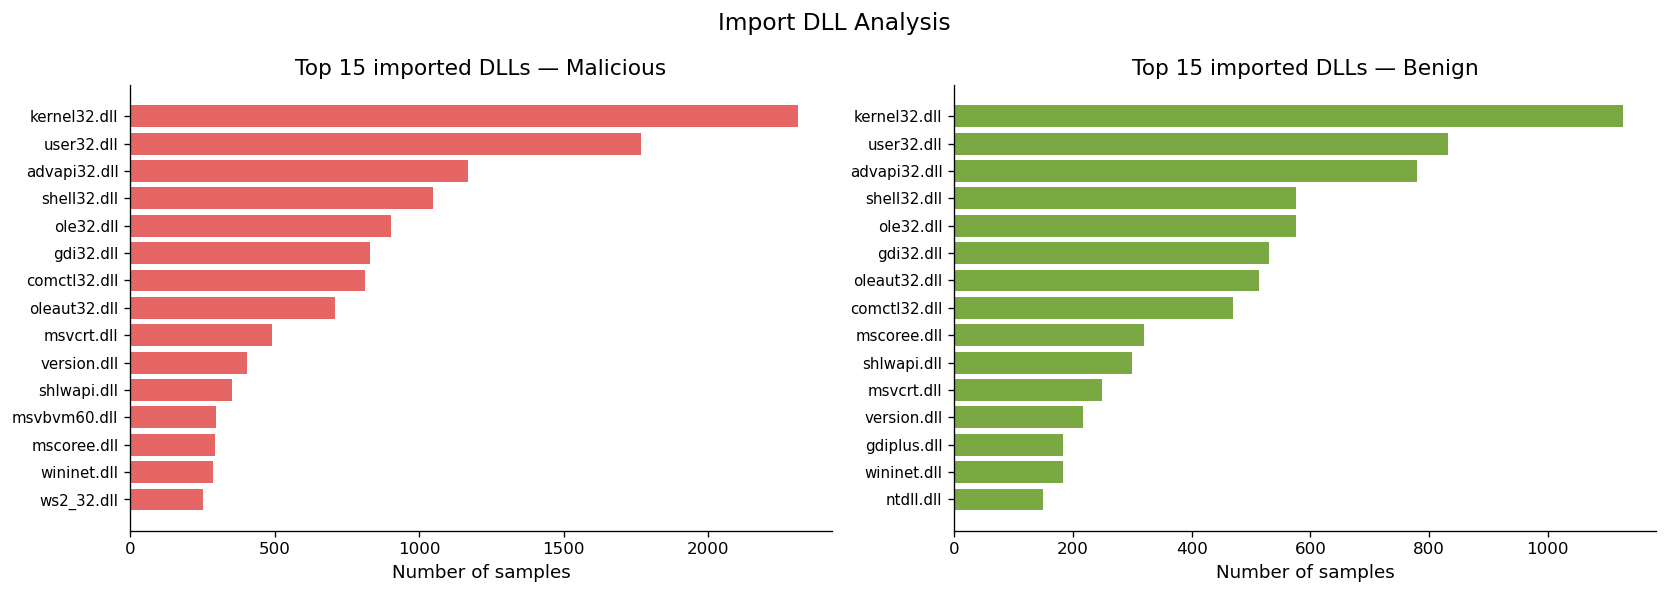


Top 10 files by import count:
                                                          sha256 label_name  imports  exports  filesize
03c440349de448b93efd9f470c81cc871ef9b03c32762b624f177169cb9fadef  unlabeled    16104        0   2635264
1069a70dfa35d3d88d01eac414f92f74d68beba3533f5270bf0bc89e9eb1b8fb     benign    16004        0   2600448
6b03f82900effd79c5e19604cb157110b8d4f56f3f5014b61587b33484e1b7c1     benign    16000        0   2600448
06a640e888d0295328eab894dabfbf244dd066444d85789198d8854b18f33596     benign    14009        0   2379264
5da261d97ffee831e5921dddd548b9396f6f04775f621d7ae95395d7b599f229  unlabeled    13850     2390  29008040
0152b64bdbb0a4b09b10b003cab00698e39ae6c6758af96a4a9e0fba6e77249e     benign    12935        0   2918912
0f47f1beecb012acbcd99932e3ed6dc6c54e09294fba80e2fd487d998df30e6d     benign    12935        0   2189312
0bdd8afb6a1c65b5cb8e69e85d9eca7e72172b31b85d0098c9ee1c255c28647d     benign    12899        0   1965568
ba3135fb7dba53508903f54d2ef04b417

In [101]:
def extract_imports(records, label_filter=None, n=5000):
    mal_dlls, ben_dlls = Counter(), Counter()
    count = 0
    for rec in records:
        lbl = rec.get('label', -1)
        if label_filter is not None and lbl not in label_filter:
            continue
        dlls = rec.get('imports', {})
        for dll in dlls:
            dll_lower = dll.lower()
            if lbl == 1:
                mal_dlls[dll_lower] += 1
            elif lbl == 0:
                ben_dlls[dll_lower] += 1
        count += 1
        if count >= n:
            break
    return mal_dlls, ben_dlls

mal_dlls, ben_dlls = extract_imports(raw_records, label_filter=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dlls, label, color in [
    (axes[0], mal_dlls, 'Malicious', PALETTE['malicious']),
    (axes[1], ben_dlls, 'Benign',    PALETTE['benign']),
]:
    top = dlls.most_common(15)
    names = [t[0] for t in top][::-1]
    vals  = [t[1] for t in top][::-1]
    ax.barh(names, vals, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 15 imported DLLs — {label}')
    ax.set_xlabel('Number of samples')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Import DLL Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('figs/ember_imports.png', bbox_inches='tight')
plt.show()

# Files with most imports vs exports
print("\nTop 10 files by import count:")
print(df.nlargest(10, 'imports')[['sha256', 'label_name', 'imports', 'exports', 'filesize']].to_string(index=False))

## 9. Header & General Feature Analysis

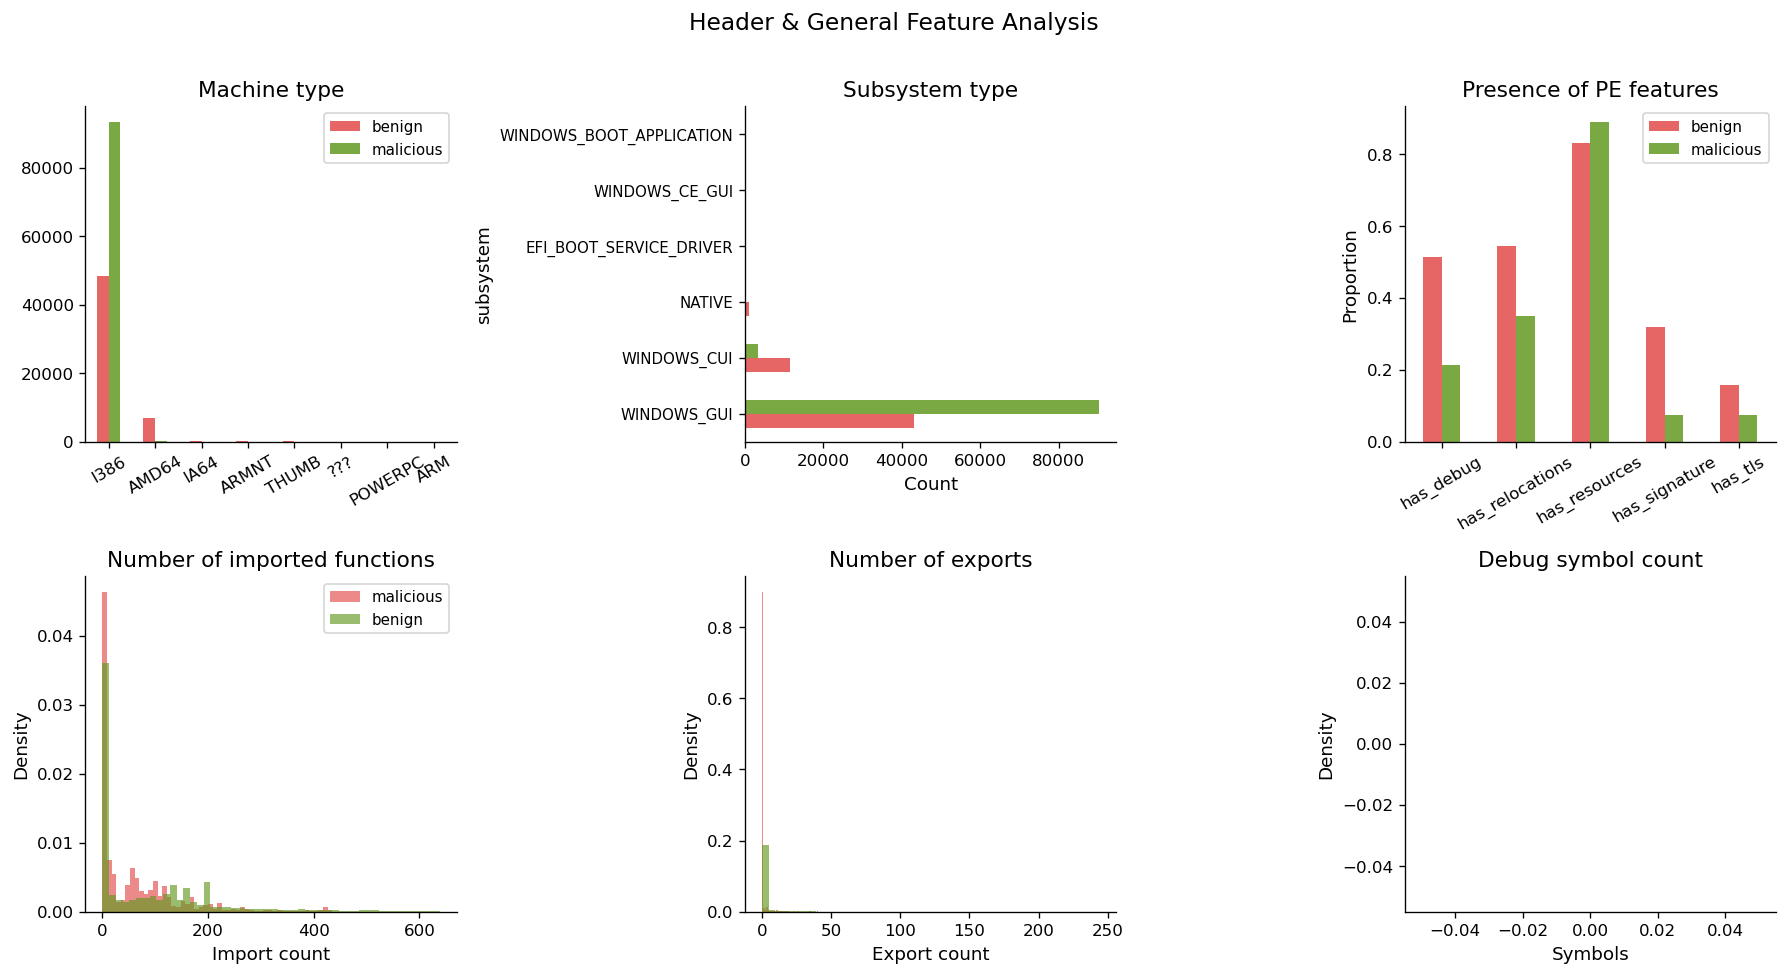

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
labeled_df = df[df['label_name'].isin(['malicious', 'benign'])].copy()

# 1. Machine type
machine_counts = labeled_df.groupby(['machine', 'label_name']).size().unstack(fill_value=0)
machine_counts = machine_counts.loc[machine_counts.sum(axis=1).nlargest(8).index]
machine_counts.plot(kind='bar', ax=axes[0], color=[PALETTE['malicious'], PALETTE['benign']],
                    edgecolor='none', alpha=0.85)
axes[0].set_title('Machine type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# 2. Subsystem
sub_counts = labeled_df.groupby(['subsystem', 'label_name']).size().unstack(fill_value=0)
sub_counts = sub_counts.loc[sub_counts.sum(axis=1).nlargest(6).index]
sub_counts.plot(kind='barh', ax=axes[1], color=[PALETTE['malicious'], PALETTE['benign']],
                edgecolor='none', alpha=0.85)
axes[1].set_title('Subsystem type')
axes[1].set_xlabel('Count')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].get_legend().remove()

# 3. Boolean features
bool_cols = ['has_debug', 'has_relocations', 'has_resources', 'has_signature', 'has_tls']
bool_rates = labeled_df.groupby('label_name')[bool_cols].mean()
bool_rates.T.plot(kind='bar', ax=axes[2],
                  color=[PALETTE['malicious'], PALETTE['benign']],
                  edgecolor='none', alpha=0.85)
axes[2].set_title('Presence of PE features')
axes[2].set_ylabel('Proportion')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=9)

# 4. Imports count
for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
    vals = labeled_df[labeled_df['label_name'] == label]['imports'].dropna()
    vals = vals[vals < vals.quantile(0.98)]
    axes[3].hist(vals, bins=50, alpha=0.65, color=color, label=label,
                 density=True, edgecolor='none')
axes[3].set_title('Number of imported functions')
axes[3].set_xlabel('Import count')
axes[3].set_ylabel('Density')
axes[3].legend(fontsize=9)

# 5. Exports count
for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
    vals = labeled_df[labeled_df['label_name'] == label]['exports'].dropna()
    vals = vals[vals < vals.quantile(0.98)]
    axes[4].hist(vals, bins=50, alpha=0.65, color=color, label=label,
                 density=True, edgecolor='none')
axes[4].set_title('Number of exports')
axes[4].set_xlabel('Export count')
axes[4].set_ylabel('Density')

# 6. Symbols
for label, color in [('malicious', PALETTE['malicious']), ('benign', PALETTE['benign'])]:
    vals = labeled_df[labeled_df['label_name'] == label]['symbols'].dropna()
    vals = vals[vals < vals.quantile(0.98)]
    axes[5].hist(vals, bins=50, alpha=0.65, color=color, label=label,
                 density=True, edgecolor='none')
axes[5].set_title('Debug symbol count')
axes[5].set_xlabel('Symbols')
axes[5].set_ylabel('Density')

plt.suptitle('Header & General Feature Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figs/ember_header.png', bbox_inches='tight')
plt.show()

## 10. Correlation Heatmap

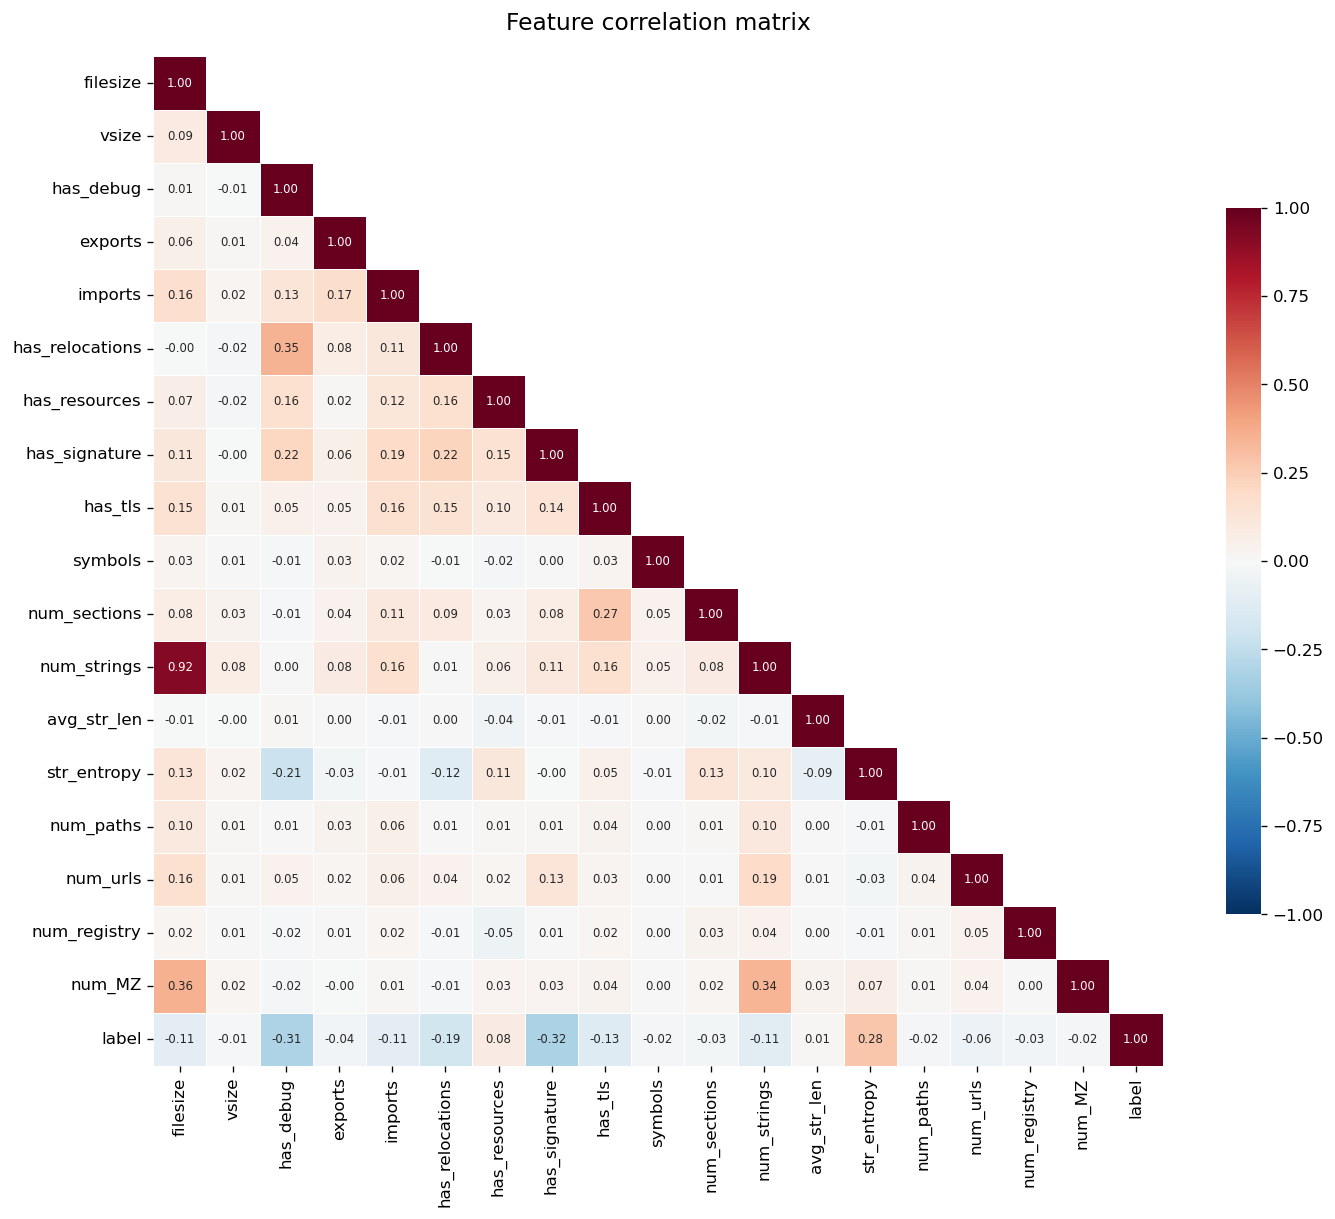


Top features correlated with label (malicious=1, benign=0):
has_signature      0.317526
has_debug          0.308856
str_entropy        0.277643
has_relocations    0.190611
has_tls            0.131326
num_strings        0.110840
filesize           0.107476
imports            0.106880
has_resources      0.083317
num_urls           0.062268
exports            0.038713
num_registry       0.033738
num_sections       0.028133
num_MZ             0.016301
symbols            0.016278
num_paths          0.016208
avg_str_len        0.011493
vsize              0.009012


In [103]:
numeric_cols = [
    'filesize', 'vsize', 'has_debug', 'exports', 'imports',
    'has_relocations', 'has_resources', 'has_signature', 'has_tls',
    'symbols', 'num_sections', 'num_strings', 'avg_str_len',
    'str_entropy', 'num_paths', 'num_urls', 'num_registry', 'num_MZ'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = labeled_df[numeric_cols + ['label']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7},
    square=True, cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature correlation matrix', fontsize=14, pad=16)
plt.tight_layout()
plt.savefig('figs/ember_corr.png', bbox_inches='tight')
plt.show()

# Correlations with label
print("\nTop features correlated with label (malicious=1, benign=0):")
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print(label_corr.to_string())

## 11. Vectorized Feature EDA (PCA + t-SNE)

> Requires `ember.create_vectorized_features()` to have been run first.

In [104]:
if EMBER_AVAILABLE:
    try:
        X_train, y_train, X_test, y_test = ember.read_vectorized_features(DATA_DIR)
        print(f"Vectorized features loaded: X_train={X_train.shape}, y_train={y_train.shape}")

        # Work only on labeled training samples
        labeled_mask = y_train != -1
        X_lab = X_train[labeled_mask]
        y_lab = y_train[labeled_mask]

        # Sample for speed
        idx = np.random.choice(len(X_lab), size=min(5000, len(X_lab)), replace=False)
        X_s, y_s = X_lab[idx], y_lab[idx]

        # Standardise
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X_s)

        # PCA
        pca = PCA(n_components=50, random_state=42)
        X_pca = pca.fit_transform(X_sc)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Explained variance
        axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100,
                     color=PALETTE['blue'], linewidth=1.8)
        axes[0].axhline(90, color='gray', linestyle='--', linewidth=0.8, label='90%')
        axes[0].set_title('PCA — cumulative explained variance')
        axes[0].set_xlabel('Number of components')
        axes[0].set_ylabel('Cumulative variance (%)')
        axes[0].legend(fontsize=9)

        # PCA scatter (PC1 vs PC2)
        for label, color, name in [(1, PALETTE['malicious'], 'malicious'),
                                    (0, PALETTE['benign'],    'benign')]:
            mask = y_s == label
            axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                            c=color, s=5, alpha=0.4, label=name, edgecolors='none')
        axes[1].set_title('PCA — PC1 vs PC2')
        axes[1].set_xlabel('PC1')
        axes[1].set_ylabel('PC2')
        axes[1].legend(markerscale=3, fontsize=9)

        # t-SNE on PCA-reduced data
        print("Running t-SNE (may take a minute)...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=500)
        X_tsne = tsne.fit_transform(X_pca[:2000])  # cap for speed
        y_tsne = y_s[:2000]
        for label, color, name in [(1, PALETTE['malicious'], 'malicious'),
                                    (0, PALETTE['benign'],    'benign')]:
            mask = y_tsne == label
            axes[2].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                            c=color, s=6, alpha=0.5, label=name, edgecolors='none')
        axes[2].set_title('t-SNE projection (2,000 samples)')
        axes[2].set_xlabel('TSNE-1')
        axes[2].set_ylabel('TSNE-2')
        axes[2].legend(markerscale=2, fontsize=9)

        plt.suptitle('Vectorized Feature Projections', fontsize=14)
        plt.tight_layout()
        plt.savefig('figs/ember_projections.png', bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Could not load vectorized features: {e}")
        print("Run: ember.create_vectorized_features(DATA_DIR) first.")
else:
    print("ember module not available — skipping vectorized feature analysis.")

Could not load vectorized features: [Errno 2] No such file or directory: './data/ember2018/y_test.dat'
Run: ember.create_vectorized_features(DATA_DIR) first.


## 12. Benchmark Model Training & Evaluation

In [105]:
if EMBER_AVAILABLE:
    try:
        import lightgbm as lgb
        from sklearn.metrics import (accuracy_score, classification_report,
                                     roc_auc_score, roc_curve, confusion_matrix)

        X_train, y_train, X_test, y_test = ember.read_vectorized_features(DATA_DIR)

        # Filter unlabeled
        train_mask = y_train != -1
        X_tr, y_tr = X_train[train_mask], y_train[train_mask]

        print("Training LightGBM...")
        params = {
            'boosting_type': 'gbdt',
            'objective': 'binary',
            'num_leaves': 2048,
            'learning_rate': 0.05,
            'feature_fraction': 0.5,
            'verbosity': -1,
        }
        lgb_train = lgb.Dataset(X_tr, label=y_tr)
        model = lgb.train(params, lgb_train, num_boost_round=1000)

        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob >= 0.5).astype(int)

        print("\nTest set performance:")
        print(f"ROC AUC  : {roc_auc_score(y_test, y_pred_prob):.6f}")
        print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification report:")
        print(classification_report(y_test, y_pred, target_names=['benign','malicious']))

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=PALETTE['blue'], lw=1.8,
                     label=f'AUC = {roc_auc:.4f}')
        axes[0].plot([0,1],[0,1], '--', color='gray', lw=0.8)
        axes[0].set_title('ROC curve')
        axes[0].set_xlabel('False positive rate')
        axes[0].set_ylabel('True positive rate')
        axes[0].legend(fontsize=10)

        # Detection at low FPR
        fprs_target = [0.001, 0.01, 0.05, 0.10]
        tprs_at = []
        for fp in fprs_target:
            idx_close = np.argmin(np.abs(fpr - fp))
            tprs_at.append(tpr[idx_close])
        axes[1].bar([f'{p*100:.1f}%' for p in fprs_target], tprs_at,
                    color=PALETTE['teal'], edgecolor='none', alpha=0.85)
        axes[1].set_title('True positive rate at fixed FPR')
        axes[1].set_xlabel('False positive rate threshold')
        axes[1].set_ylabel('True positive rate')
        axes[1].set_ylim(0.8, 1.0)
        for i, v in enumerate(tprs_at):
            axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues',
                    xticklabels=['benign','malicious'],
                    yticklabels=['benign','malicious'],
                    linewidths=0.5, cbar=False)
        axes[2].set_title('Confusion matrix')
        axes[2].set_xlabel('Predicted')
        axes[2].set_ylabel('Actual')

        plt.suptitle('LightGBM Benchmark Model — Test Set Results', fontsize=14)
        plt.tight_layout()
        plt.savefig('ember_model_perf.png', bbox_inches='tight')
        plt.show()

        # Feature importance
        fi = pd.Series(model.feature_importance(importance_type='gain'))
        top_fi = fi.nlargest(30)
        fig, ax = plt.subplots(figsize=(8, 7))
        ax.barh(top_fi.index, top_fi.values, color=PALETTE['purple'], alpha=0.8)
        ax.set_title('Top 30 features by gain importance')
        ax.set_xlabel('Gain importance')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig('figs/ember_feature_importance.png', bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Model training skipped: {e}")
else:
    print("ember module not available — skipping model training.")

Model training skipped: [Errno 2] No such file or directory: './data/ember2018/y_test.dat'


## 13. EDA Summary

In [106]:
summary = {
    'Total samples': len(df),
    'Malicious': int((df['label'] == 1).sum()),
    'Benign': int((df['label'] == 0).sum()),
    'Unlabeled': int((df['label'] == -1).sum()),
    'Median malicious file size (KB)': round(df[df['label']==1]['filesize'].median() / 1024, 1),
    'Median benign file size (KB)': round(df[df['label']==0]['filesize'].median() / 1024, 1),
    'Has signature (malicious %)': round(df[df['label']==1]['has_signature'].mean() * 100, 1),
    'Has signature (benign %)': round(df[df['label']==0]['has_signature'].mean() * 100, 1),
    'Median imports (malicious)': df[df['label']==1]['imports'].median(),
    'Median imports (benign)': df[df['label']==0]['imports'].median(),
    'Median string entropy (malicious)': round(df[df['label']==1]['str_entropy'].median(), 3),
    'Median string entropy (benign)': round(df[df['label']==0]['str_entropy'].median(), 3),
}

print("\n" + "=" * 50)
print(" EMBER EDA — Key Findings")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<45} {v}")


 EMBER EDA — Key Findings
  Total samples                                 202574
  Malicious                                     93521
  Benign                                        55662
  Unlabeled                                     53391
  Median malicious file size (KB)               495.0
  Median benign file size (KB)                  377.5
  Has signature (malicious %)                   7.4
  Has signature (benign %)                      31.8
  Median imports (malicious)                    25.0
  Median imports (benign)                       38.0
  Median string entropy (malicious)             6.179
  Median string entropy (benign)                5.715
